This notebook provides a graphical analysis of all the aggregated data (INFO284 + IGSIN919 + INF266) collected during the survey.

Some of this code (especially the optimized visualization) was generated with the support of Anthropic Claude. No data was shared or uploade to Anthropic Claude.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data loading

In [2]:
df = pd.read_csv('data.csv', encoding='latin-1')
df.head()

,Group,"1. On average, how many hours per week do you use AI tools for this course?\n",2. Which AI tools do you regularly use for this course? - ChatGPT,2. Which AI tools do you regularly use for this course? - Gemini,2. Which AI tools do you regularly use for this course? - Claude,2. Which AI tools do you regularly use for this course? - Copilot,2. Which AI tools do you regularly use for this course? - DeepSeek,2. Which AI tools do you regularly use for this course? - Grok,2. Which AI tools do you regularly use for this course? - Other (specify),2. Which AI tools do you regularly use for this course? - Other (specify).1,...,8. How do you think of an AI tool while interacting with it? - A text or code generator,8. How do you think of an AI tool while interacting with it? - A knowledge interface,8. How do you think of an AI tool while interacting with it? - Other (specify),8. How do you think of an AI tool while interacting with it? - Other (specify).1,"Thank you for participating in the survey! If you have any comments regarding the survey, you can leave them here.",Overall Status - New,Overall Status - Distributed,Overall Status - Partially Complete,Overall Status - Complete,Overall Status - Rejected
0,INFO284,More than 6,1,0,0,1,0,0,1,Github copilot,...,0,1,0,NaN,NaN,0,0,0,1,0
1,INFO284,1-2,1,0,1,1,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0
2,INFO284,2-4,1,0,0,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
3,INFO284,2-4,1,0,1,0,0,0,0,NaN,...,0,0,0,NaN,NaN,0,0,0,1,0
4,INFO284,4-6,1,0,1,0,0,0,0,NaN,...,1,0,0,NaN,NaN,0,0,0,1,0


### Question 1

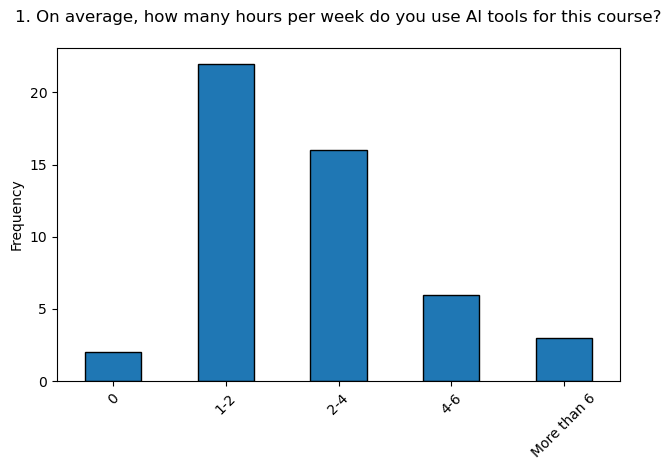

In [3]:
custom_order = ['0', '1-2', '2-4', '4-6', 'More than 6']  # replace with your actual categories

# Count occurrences, then reindex to your order
counts = df.iloc[:, 1].value_counts()
counts = counts.reindex(custom_order)

# Plot
counts.plot(kind='bar', edgecolor='black')
plt.xlabel('')
plt.ylabel('Frequency')
plt.title(f'{df.iloc[:, 1].name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

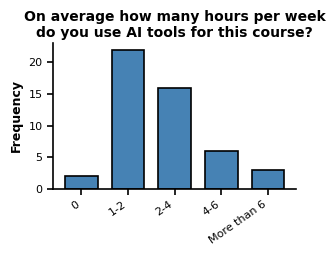

In [12]:
custom_order = ['0', '1-2', '2-4', '4-6', 'More than 6']

counts = df.iloc[:, 1].value_counts()
counts = counts.reindex(custom_order)

fig, ax = plt.subplots(figsize=(3, 2.5))  # Small but intentional size

counts.plot(
    kind='bar',
    edgecolor='black',
    linewidth=1.2,        # Thicker bar edges
    ax=ax,
    color='steelblue',    # Explicit color — poster printers can shift defaults
    width=0.7,            # Slightly narrower bars give breathing room
)

ax.set_xlabel('', fontsize=0)
ax.set_ylabel('Frequency', fontsize=9, fontweight='bold')
ax.set_title('On average how many hours per week\ndo you use AI tools for this course?', fontsize=10, fontweight='bold', pad=4)
ax.tick_params(axis='both', labelsize=8, width=1.2, length=4)
ax.set_xticklabels(custom_order, rotation=35, ha='right', fontsize=8)

# Remove top and right spines — reduces visual clutter at small sizes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout(pad=0.5)
plt.savefig('Q1.png', dpi=300, bbox_inches='tight')  # High DPI for print
plt.show()

### Question 2

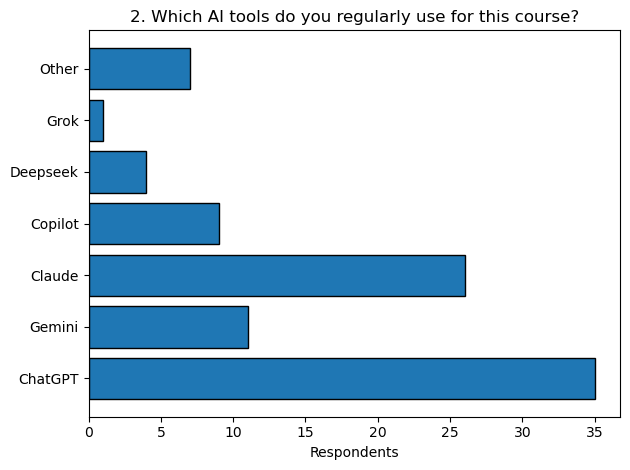

In [6]:
labels = ['ChatGPT', 'Gemini', 'Claude', 'Copilot', 'Deepseek', 'Grok', 'Other']
sums = [df.iloc[:, i].sum() for i in np.arange(2,9)]

plt.barh(labels, sums, edgecolor='black')
plt.xlabel('Respondents')
plt.title('2. Which AI tools do you regularly use for this course?')
plt.tight_layout()
plt.show()

### Question 3

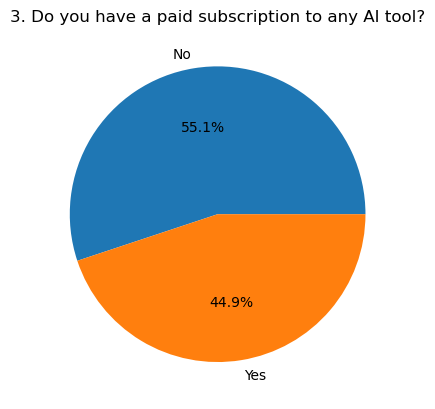

In [7]:
col10 = df.iloc[:, 10]

col10.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')  # hides the default y-label
plt.title(f'{col10.name}')
plt.show()

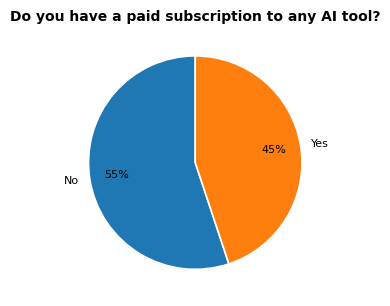

In [13]:
col10 = df.iloc[:, 10]

fig, ax = plt.subplots(figsize=(3, 3))  # Square keeps the pie circular

col10.value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',        # Drop the decimal — saves space on small slices
    ax=ax,
    startangle=90,            # Cleaner starting position
    pctdistance=0.75,         # Pull percentages inward, away from edges
    wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'},  # Clear slice separation
    textprops={'fontsize': 8},
)

# Format percentage labels
for text in ax.texts:
    text.set_fontsize(8)

ax.set_ylabel('')
ax.set_title(
    'Do you have a paid subscription to any AI tool?',
    fontsize=10,
    fontweight='bold',
    pad=6,
)

plt.tight_layout(pad=0.5)
plt.savefig('Q3.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 4

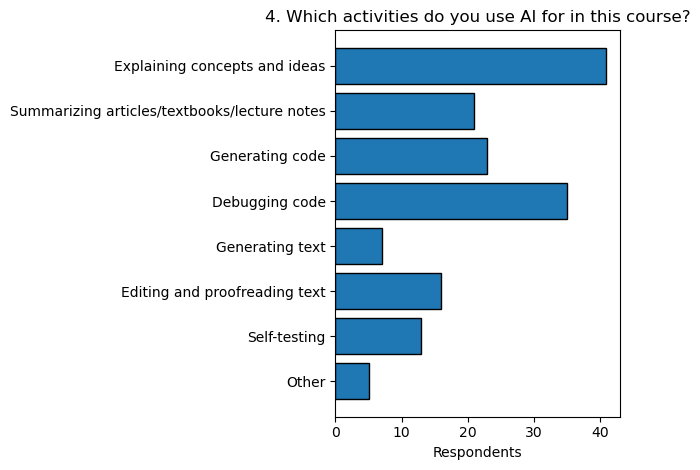

In [6]:
labels = ['Explaining concepts and ideas',
          'Summarizing articles/textbooks/lecture notes',
          'Generating code', 
          'Debugging code',
          'Generating text',
          'Editing and proofreading text',
          'Self-testing',
          'Other']
sums = [df.iloc[:, i].sum() for i in np.arange(11,19)]

plt.barh(labels[::-1], sums[::-1], edgecolor='black')
plt.xlabel('Respondents')
plt.title('4. Which activities do you use AI for in this course?')
plt.tight_layout()
plt.show()

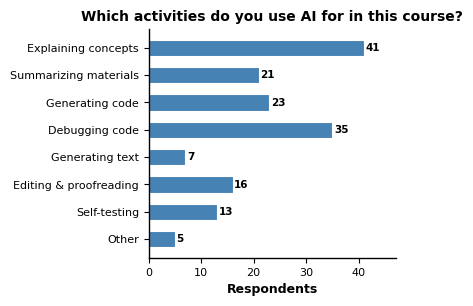

In [14]:
labels = [
    'Explaining concepts',        # Shortened for readability
    'Summarizing materials',
    'Generating code',
    'Debugging code',
    'Generating text',
    'Editing & proofreading',
    'Self-testing',
    'Other',
]

sums = [df.iloc[:, i].sum() for i in np.arange(11, 19)]

fig, ax = plt.subplots(figsize=(4, 3))

bars = ax.barh(
    labels[::-1],
    sums[::-1],
    edgecolor='white',            # White edges cleaner than black for horizontal bars
    linewidth=0.8,
    color='steelblue',
    height=0.6,                   # Slightly thinner bars give breathing room
)

# Add value labels at the end of each bar — avoids needing to read the x-axis
for bar, val in zip(bars, sums[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(int(val)),
        va='center', ha='left',
        fontsize=7.5, fontweight='bold',
    )

ax.set_xlabel('Respondents', fontsize=9, fontweight='bold')
ax.set_title(
    'Which activities do you use AI for in this course?',
    fontsize=10,
    fontweight='bold',
    pad=6,
)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Extend x-axis slightly to make room for value labels
ax.set_xlim(0, max(sums) * 1.15)

plt.tight_layout(pad=0.5)
plt.savefig('Q4.png', dpi=300, bbox_inches='tight')
plt.show()

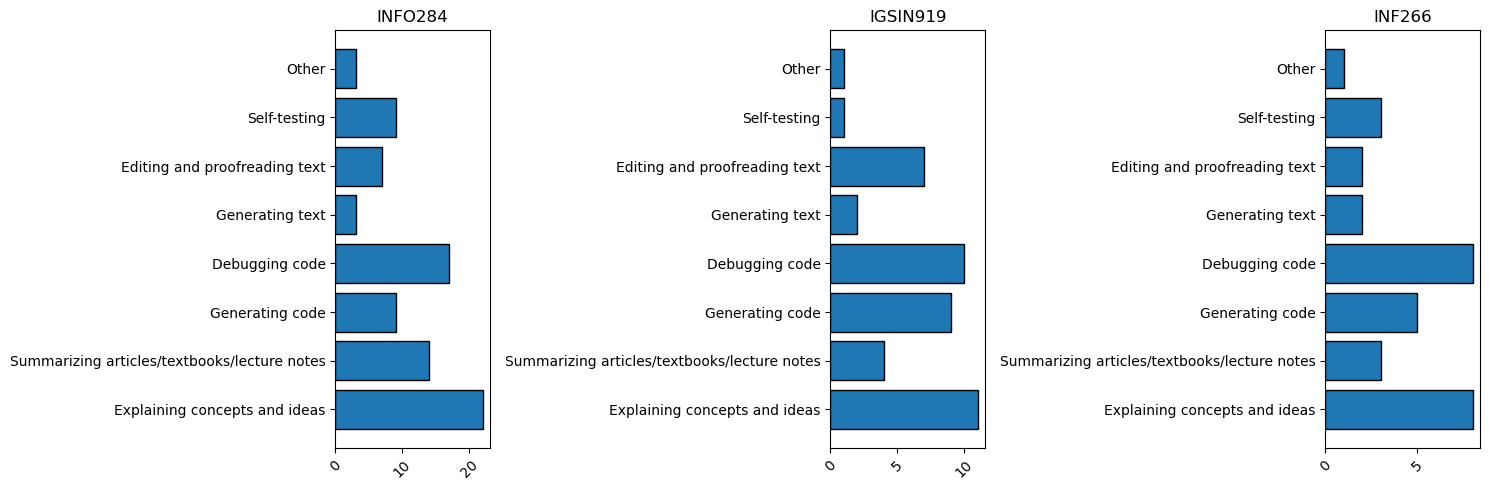

In [7]:
labels = ['Explaining concepts and ideas',
          'Summarizing articles/textbooks/lecture notes',
          'Generating code', 
          'Debugging code',
          'Generating text',
          'Editing and proofreading text',
          'Self-testing',
          'Other']

val1, val2, val3 = 'INFO284', 'IGSIN919', 'INF266'  # replace with your actual values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, val in zip(axes, [val1, val2, val3]):
    filtered = df[df.iloc[:, 0] == val]
    sums = [filtered.iloc[:, i].sum() for i in np.arange(11,19)]
    ax.barh(labels, sums, edgecolor='black')
    ax.set_title(f'{val}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Question 5

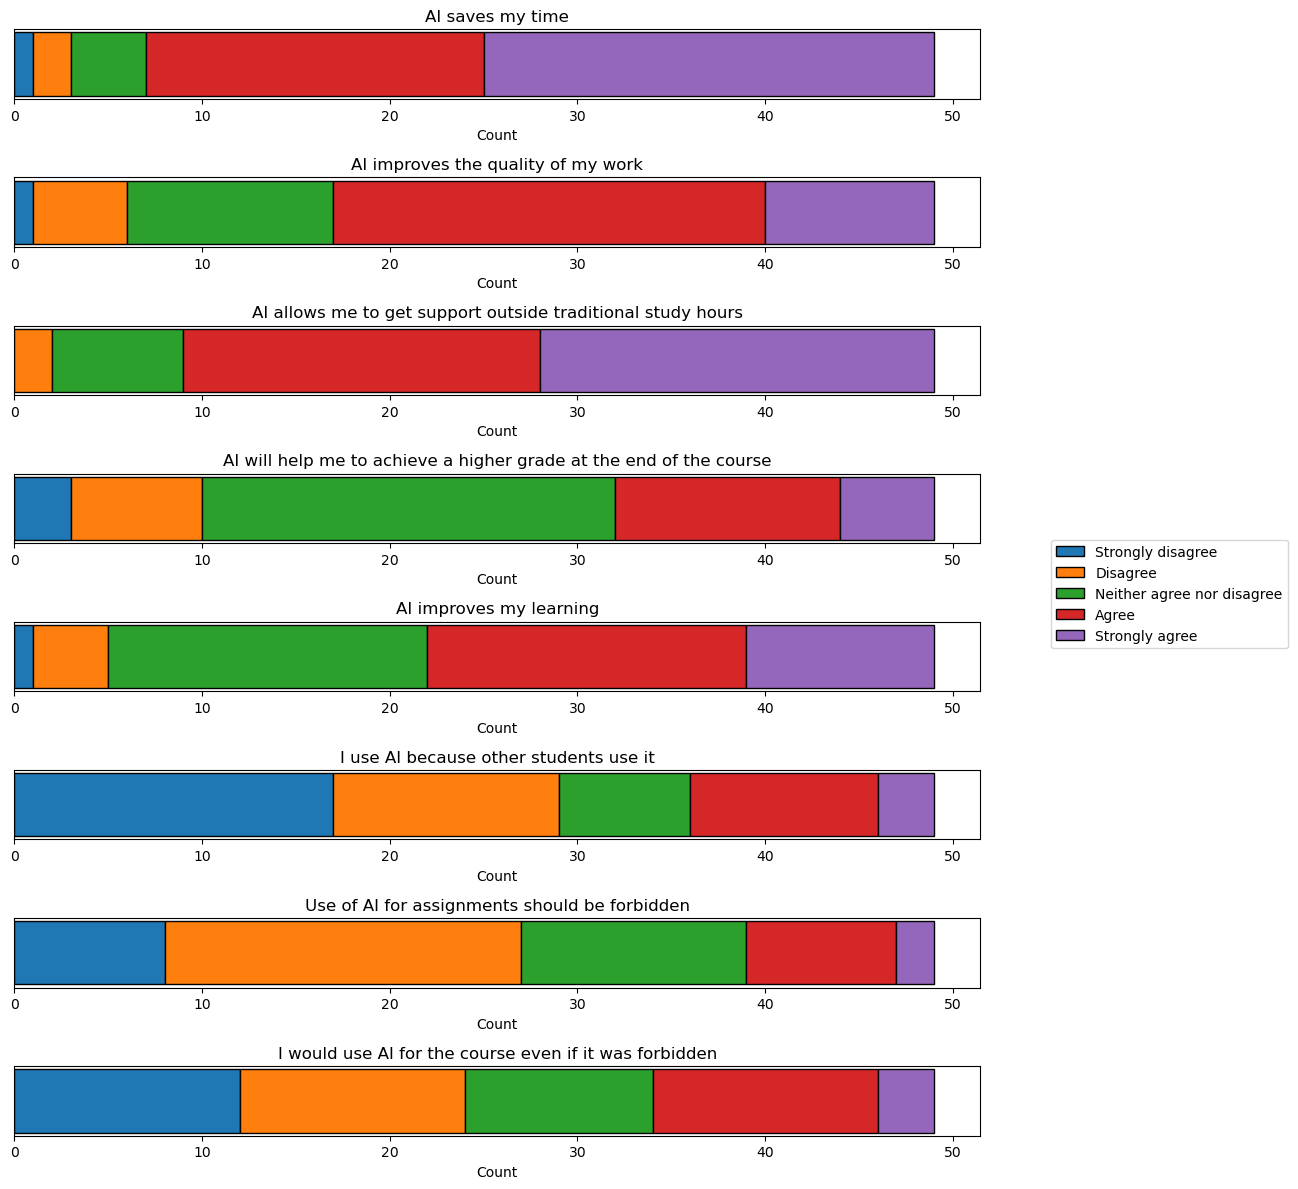

In [20]:
cols = [df.iloc[:, i] for i in range(20,28)]
labels = ['AI saves my time',
          'AI improves the quality of my work', 
          'AI allows me to get support outside traditional study hours',
          'AI will help me to achieve a higher grade at the end of the course',
         'AI improves my learning',
         'I use AI because other students use it',
         'Use of AI for assignments should be forbidden',
         'I would use AI for the course even if it was forbidden']

fig, axes = plt.subplots(8, 1, figsize=(10, 12))

for ax, col, i in zip(axes, cols, range(len(labels))):
    counts = col.value_counts().reindex(['Strongly disagree', 'Disagree', 'Neither agree nor disagree', 'Agree', 'Strongly agree'], fill_value=0)
    left = 0
    for category, value in counts.items():
        ax.barh(0, value, left=left, label=category, edgecolor='black')
        left += value
    ax.set_yticks([])
    ax.set_xlabel('Count')
    #ax.set_ylabel(labels[i],rotation=0)
    ax.set_title(labels[i])
    #ax.legend(loc='upper right', bbox_to_anchor=(1, 1.5))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

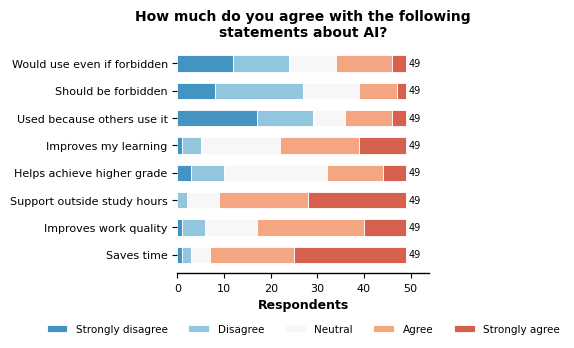

In [22]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np

short_labels = [
    'Saves time',
    'Improves work quality',
    'Support outside study hours',
    'Helps achieve higher grade',
    'Improves my learning',
    'Used because others use it',
    'Should be forbidden',
    'Would use even if forbidden',
]

data_keys     = ['Strongly disagree', 'Disagree', 'Neither agree nor disagree', 'Agree', 'Strongly agree']
display_labels = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']
colors         = ['#4393c3', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d']

cols = [df.iloc[:, i] for i in range(20, 28)]

# Build data matrix
data = []
for col in cols:
    counts = col.value_counts().reindex(data_keys, fill_value=0)
    data.append(counts.values)
data = np.array(data)

fig, ax = plt.subplots(figsize=(5, 3.5))
y_pos = np.arange(len(short_labels))
lefts = np.zeros(len(short_labels))

for j, (display, color) in enumerate(zip(display_labels, colors)):
    ax.barh(
        y_pos, data[:, j], left=lefts,
        color=color, edgecolor='white',
        linewidth=0.6, height=0.6, label=display,
    )
    lefts += data[:, j]

# Total count labels
for i, total in enumerate(data.sum(axis=1)):
    ax.text(total + 0.5, i, str(int(total)),
            va='center', ha='left', fontsize=7)

ax.set_yticks(y_pos)
ax.set_yticklabels(short_labels, fontsize=8)
ax.set_xlabel('Respondents', fontsize=9, fontweight='bold')
ax.set_title(
    '\n'.join(textwrap.wrap('How much do you agree with the following statements about AI?', width=45)),
    fontsize=10, fontweight='bold', pad=6,
)
ax.tick_params(axis='x', labelsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)

ax.legend(
    display_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=5, fontsize=7.5, frameon=False,
)

ax.set_xlim(0, data.sum(axis=1).max() * 1.1)
plt.tight_layout(pad=0.5)
plt.savefig('Q5.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 6

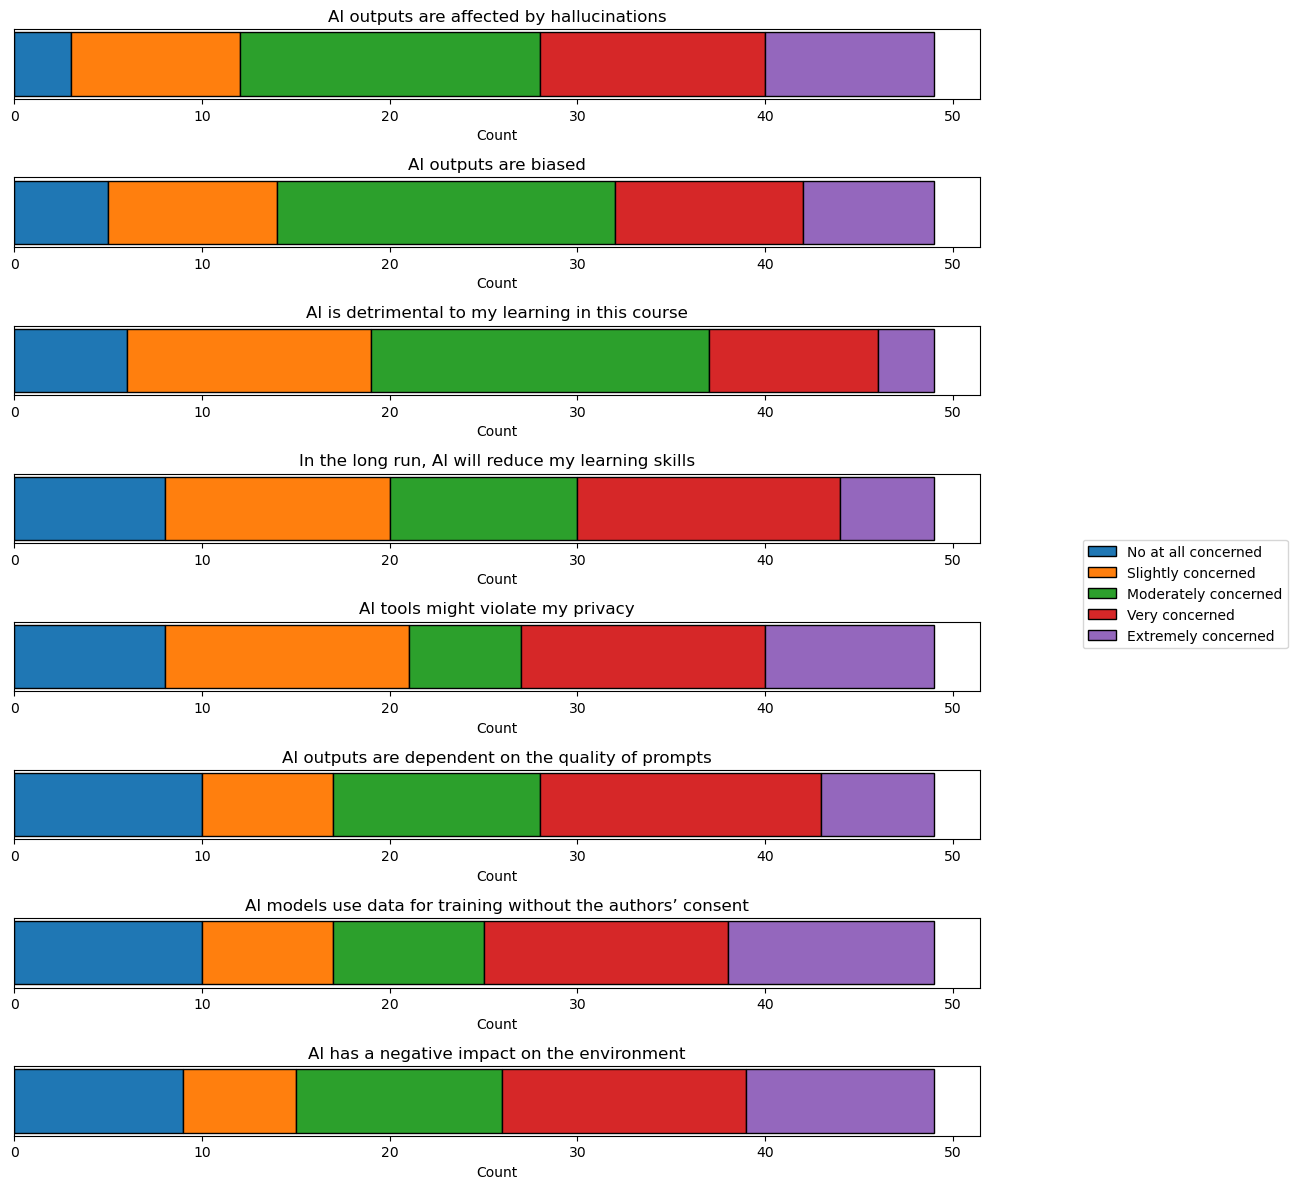

In [16]:
cols = [df.iloc[:, i] for i in range(28,36)]
labels = ['AI outputs are affected by hallucinations',
          'AI outputs are biased', 
          'AI is detrimental to my learning in this course',
          'In the long run, AI will reduce my learning skills',
         'AI tools might violate my privacy',
         'AI outputs are dependent on the quality of prompts',
         'AI models use data for training without the authors’ consent',
         'AI has a negative impact on the environment']

fig, axes = plt.subplots(8, 1, figsize=(10, 12))

for ax, col, i in zip(axes, cols, range(len(labels))):
    counts = col.value_counts().reindex(['No at all concerned', 'Slightly concerned', 'Moderately concerned', 'Very concerned', 'Extremely concerned'], fill_value=0)
    left = 0
    for category, value in counts.items():
        ax.barh(0, value, left=left, label=category, edgecolor='black')
        left += value
    ax.set_yticks([])
    ax.set_xlabel('Count')
    #ax.set_ylabel(labels[i],rotation=0)
    ax.set_title(labels[i])
    #ax.legend(loc='upper right', bbox_to_anchor=(1, 1.5))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

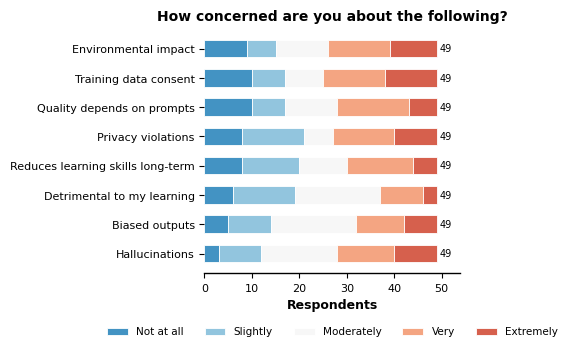

In [19]:
import textwrap
import matplotlib.pyplot as plt
import numpy as np

labels = [
    'Hallucinations',                        # Shortened labels
    'Biased outputs',
    'Detrimental to my learning',
    'Reduces learning skills long-term',
    'Privacy violations',
    'Quality depends on prompts',
    'Training data consent',
    'Environmental impact',
]

full_labels = [
    'AI outputs are affected by hallucinations',
    'AI outputs are biased',
    'AI is detrimental to my learning in this course',
    'In the long run, AI will reduce my learning skills',
    'AI tools might violate my privacy',
    'AI outputs are dependent on the quality of prompts',
    'AI models use data for training without the authors\' consent',
    'AI has a negative impact on the environment',
]

categories = ['Not at all', 'Slightly', 'Moderately', 'Very', 'Extremely']

# Diverging colormap: cool → warm, intuitive for concern levels
colors = ['#4393c3', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d']

cols = [df.iloc[:, i] for i in range(28, 36)]

fig, ax = plt.subplots(figsize=(5, 3.5))  # Single axis — much more compact

# Build data matrix
data = []
for col in cols:
    counts = col.value_counts().reindex(
        ['No at all concerned', 'Slightly concerned', 'Moderately concerned',
         'Very concerned', 'Extremely concerned'],
        fill_value=0
    )
    data.append(counts.values)
data = np.array(data)

y_pos = np.arange(len(labels))

# Plot each concern level as a stacked horizontal bar
lefts = np.zeros(len(labels))
bars = []
for j, (cat, color) in enumerate(zip(categories, colors)):
    b = ax.barh(
        y_pos,
        data[:, j],
        left=lefts,
        color=color,
        edgecolor='white',
        linewidth=0.6,
        height=0.6,
        label=cat,
    )
    bars.append(b)
    lefts += data[:, j]

# Add total respondent count at end of each bar
for i, total in enumerate(data.sum(axis=1)):
    ax.text(total + 0.5, i, str(int(total)),
            va='center', ha='left', fontsize=7)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Respondents', fontsize=9, fontweight='bold')
ax.set_title('How concerned are you about the following?',
    fontsize=10, fontweight='bold', pad=6,
)
ax.tick_params(axis='x', labelsize=8)

# Spine cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)

# Compact legend below the chart
ax.legend(
    categories,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=5,
    fontsize=7.5,
    frameon=False,
)

ax.set_xlim(0, data.sum(axis=1).max() * 1.1)
plt.tight_layout(pad=0.5)
plt.savefig('Q6.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 7

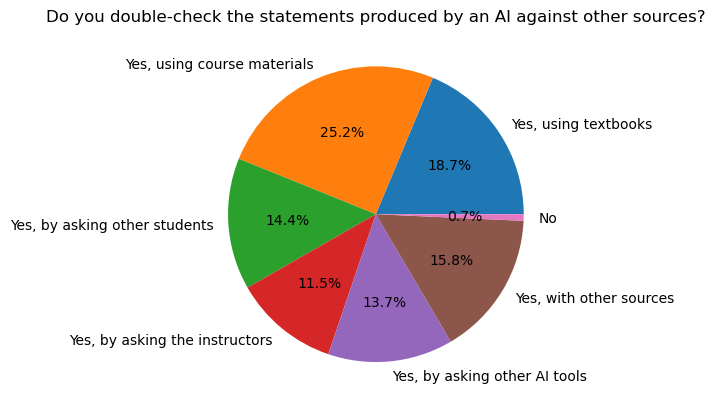

In [10]:
col10 = df.iloc[:, 36:43]
labels = ['Yes, using textbooks',
         'Yes, using course materials',
         'Yes, by asking other students',
         'Yes, by asking the instructors',
         'Yes, by asking other AI tools',
         'Yes, with other sources',
         'No']

col10.sum().plot(kind='pie', labels=labels, autopct='%1.1f%%')
plt.ylabel('')  # hides the default y-label
plt.title('Do you double-check the statements produced by an AI against other sources?')
plt.show()

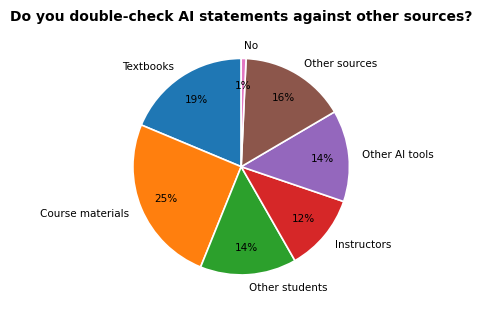

In [15]:
col10 = df.iloc[:, 36:43]
labels = [
    'Textbooks',           # Shortened labels — originals are too long for a small pie
    'Course materials',
    'Other students',
    'Instructors',
    'Other AI tools',
    'Other sources',
    'No',
]

fig, ax = plt.subplots(figsize=(4, 4))  # Slightly larger — 7 slices need more room

col10.sum().plot(
    kind='pie',
    labels=labels,
    autopct='%1.0f%%',
    ax=ax,
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.12,       # Push labels slightly outward to avoid overlap
    wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'},
    textprops={'fontsize': 7.5},
)

for text in ax.texts:
    text.set_fontsize(7.5)

ax.set_ylabel('')
ax.set_title(
    'Do you double-check AI statements against other sources?',
    fontsize=10,
    fontweight='bold',
    pad=8,
)

plt.tight_layout(pad=0.5)
plt.savefig('Q7.png', dpi=300, bbox_inches='tight')
plt.show()

### Question 8

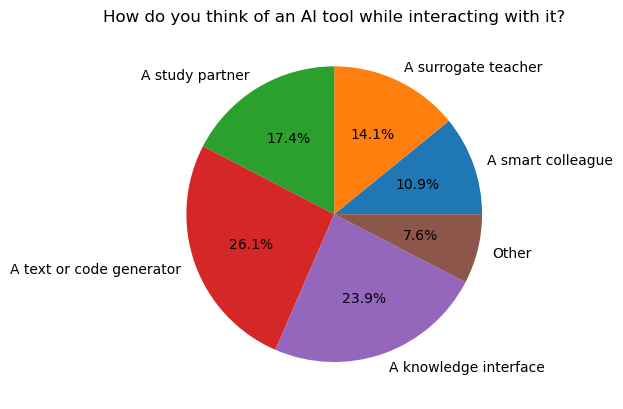

In [11]:
col10 = df.iloc[:, 44:50]
labels = ['A smart colleague',
         'A surrogate teacher',
         'A study partner',
         'A text or code generator',
         'A knowledge interface',
         'Other']

col10.sum().plot(kind='pie', labels=labels, autopct='%1.1f%%')
plt.ylabel('')  # hides the default y-label
plt.title('How do you think of an AI tool while interacting with it?')
plt.show()

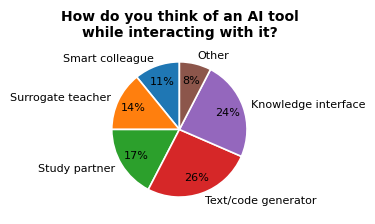

In [23]:
short_labels = [
    'Smart colleague',
    'Surrogate teacher',
    'Study partner',
    'Text/code generator',
    'Knowledge interface',
    'Other',
]

col10 = df.iloc[:, 44:50]

fig, ax = plt.subplots(figsize=(3.5, 3.5))

col10.sum().plot(
    kind='pie',
    labels=short_labels,
    autopct='%1.0f%%',
    ax=ax,
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.12,
    wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'},
    textprops={'fontsize': 8},
)

for text in ax.texts:
    text.set_fontsize(8)

ax.set_ylabel('')
ax.set_title(
    '\n'.join(textwrap.wrap('How do you think of an AI tool while interacting with it?', width=30)),
    fontsize=10, fontweight='bold', pad=6,
)

plt.tight_layout(pad=0.5)
plt.savefig('Q8.png', dpi=300, bbox_inches='tight')
plt.show()